<a href="https://colab.research.google.com/github/chaihong0522/morning/blob/main/Ind_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files

uploaded = files.upload()

Saving assignp1500 to assignp1500 (1)


In [3]:
# ============================================================
# ASSIGNMENT PROBLEM USING SIMULATED ANNEALING
# Dataset: OR-Library assignp1500
# Initial solution: Random feasible assignment
# Neighbourhood: SWAP two assigned tasks
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import math
import time
import csv

# ------------------------------------------------------------
# 1. READ SPARSE ASSIGNMENT DATASET
# ------------------------------------------------------------

filename = "assignp1500"

with open(filename, "r") as file:
    n = int(file.readline().strip())

    # cost_matrix[i][j] stores assignment cost.
    # -1 means assignment i -> j is not allowed.
    cost_matrix = np.full((n, n), -1, dtype=np.int16)

    # Store possible tasks for each worker.
    row_candidates = [[] for _ in range(n)]

    # Store workers that can be assigned to each task.
    col_rows = [[] for _ in range(n)]

    edge_count = 0

    for line in file:
        parts = line.split()

        if len(parts) == 3:
            i, j, cost = map(int, parts)

            # Change index from 1-based to 0-based.
            i = i - 1
            j = j - 1

            cost_matrix[i][j] = cost
            row_candidates[i].append(j)
            col_rows[j].append(i)

            edge_count += 1

# Convert lists into NumPy arrays for faster searching.
col_rows = [np.array(rows, dtype=np.int32) for rows in col_rows]

# Sort each worker's feasible tasks by assignment cost.
for i in range(n):
    row_candidates[i].sort(key=lambda j: cost_matrix[i][j])

print("Dataset successfully loaded.")
print("Number of workers/tasks:", n)
print("Number of valid assignment pairs:", edge_count)
print("Average valid tasks per worker:", round(edge_count / n, 2))

Dataset successfully loaded.
Number of workers/tasks: 1500
Number of valid assignment pairs: 99844
Average valid tasks per worker: 66.56


In [6]:
import sys

sys.setrecursionlimit(10000)
print("Recursion limit updated successfully.")

Recursion limit updated successfully.


In [7]:
# ------------------------------------------------------------
# 2. CREATE A RANDOM FEASIBLE INITIAL SOLUTION
# ------------------------------------------------------------

def create_random_feasible_solution(n, row_candidates, seed=6023):
    """
    Creates a random but feasible one-to-one assignment.

    A worker is assigned to exactly one task.
    A task is assigned to exactly one worker.
    Only valid assignment pairs from the sparse dataset are used.
    """

    rng = np.random.default_rng(seed)

    # Workers with fewer available tasks are handled first.
    # This reduces the chance of infeasible assignment.
    row_order = sorted(range(n), key=lambda i: len(row_candidates[i]))

    # Randomise feasible task choices for every worker.
    shuffled_candidates = []

    for i in range(n):
        choices = np.array(row_candidates[i], dtype=np.int32)
        rng.shuffle(choices)
        shuffled_candidates.append(choices)

    # col_to_row[j] tells which worker is assigned to task j.
    col_to_row = [-1] * n

    def augment(worker, visited_tasks):
        """
        Augmenting-path method:
        tries to find a valid task for the current worker.
        """

        for task_value in shuffled_candidates[worker]:
            task = int(task_value)

            if task in visited_tasks:
                continue

            visited_tasks.add(task)

            previous_worker = col_to_row[task]

            # Task is empty, or previous worker can move elsewhere.
            if previous_worker == -1 or augment(previous_worker, visited_tasks):
                col_to_row[task] = worker
                return True

        return False

    # Find a feasible task for every worker.
    for worker in row_order:
        if not augment(worker, set()):
            raise ValueError("Unable to generate a feasible assignment.")

    # Convert task-to-worker assignment into worker-to-task assignment.
    solution = np.empty(n, dtype=np.int32)

    for task, worker in enumerate(col_to_row):
        solution[worker] = task

    return solution


def calculate_cost(solution, cost_matrix):
    """
    Calculates total assignment cost.
    """

    workers = np.arange(len(solution))
    return int(cost_matrix[workers, solution].sum())


# Create the initial random feasible assignment.
initial_solution = create_random_feasible_solution(
    n=n,
    row_candidates=row_candidates,
    seed=6023
)

initial_cost = calculate_cost(initial_solution, cost_matrix)

print("Initial solution successfully generated.")
print("Initial objective function value:", initial_cost)
print("First 15 assignments:")

for i in range(15):
    print(f"Worker {i+1} -> Task {initial_solution[i]+1} | Cost = {cost_matrix[i][initial_solution[i]]}")

Initial solution successfully generated.
Initial objective function value: 76350
First 15 assignments:
Worker 1 -> Task 63 | Cost = 35
Worker 2 -> Task 2 | Cost = 79
Worker 3 -> Task 793 | Cost = 8
Worker 4 -> Task 1486 | Cost = 35
Worker 5 -> Task 724 | Cost = 72
Worker 6 -> Task 398 | Cost = 52
Worker 7 -> Task 121 | Cost = 96
Worker 8 -> Task 1252 | Cost = 3
Worker 9 -> Task 8 | Cost = 77
Worker 10 -> Task 1288 | Cost = 74
Worker 11 -> Task 1391 | Cost = 98
Worker 12 -> Task 94 | Cost = 32
Worker 13 -> Task 1383 | Cost = 59
Worker 14 -> Task 155 | Cost = 10
Worker 15 -> Task 1385 | Cost = 36


In [11]:
# ------------------------------------------------------------
# 3. FIND A VALID SWAP MOVE
# ------------------------------------------------------------

def find_valid_swap(solution, cost_matrix, col_rows, rng, attempts=150):
    """
    Finds two workers whose assigned tasks can be swapped legally.

    Current assignment:
    Worker i -> Task A
    Worker j -> Task B

    After SWAP:
    Worker i -> Task B
    Worker j -> Task A

    The swap is only allowed when both new assignments exist
    in the sparse assignment dataset.
    """

    n = len(solution)

    for _ in range(attempts):

        # Randomly select one worker.
        i = int(rng.integers(n))

        # Current task of worker i.
        task_i = int(solution[i])

        # Select a worker that can legally receive task_i.
        possible_workers = col_rows[task_i]

        j = int(possible_workers[rng.integers(len(possible_workers))])

        if i == j:
            continue

        task_j = int(solution[j])

        # Check whether worker i can receive worker j's task.
        if cost_matrix[i][task_j] >= 0:
            return i, j

    return None


# ------------------------------------------------------------
# 4. SIMULATED ANNEALING ALGORITHM
# ------------------------------------------------------------

def simulated_annealing(
        initial_solution,
        cost_matrix,
        col_rows,
        initial_temperature=50.0,
        cooling_rate=0.9995,
        max_iterations=15000,
        seed=6023
    ):
    """
    Improves the initial assignment using Simulated Annealing.

    Parameters:
    initial_temperature = controls acceptance of worse solutions at the start.
    cooling_rate = reduces temperature gradually.
    max_iterations = stopping condition.
    """

    rng = np.random.default_rng(seed)

    current_solution = initial_solution.copy()
    current_cost = calculate_cost(current_solution, cost_matrix)

    best_solution = current_solution.copy()
    best_cost = current_cost

    temperature = initial_temperature

    convergence = []
    accepted_moves = 0
    improving_moves = 0
    invalid_swap_attempts = 0

    start_time = time.time()

    for iteration in range(1, max_iterations + 1):

        # Generate a valid SWAP neighbour.
        move = find_valid_swap(
            current_solution,
            cost_matrix,
            col_rows,
            rng
        )

        if move is None:
            invalid_swap_attempts += 1
            continue

        i, j = move

        task_i = int(current_solution[i])
        task_j = int(current_solution[j])

        # Calculate new cost after the swap.
        new_cost = (
            current_cost
            - int(cost_matrix[i][task_i])
            - int(cost_matrix[j][task_j])
            + int(cost_matrix[i][task_j])
            + int(cost_matrix[j][task_i])
        )

        delta = new_cost - current_cost

        # Accept better solution automatically.
        # Accept worse solution with SA probability.
        if delta <= 0 or rng.random() < math.exp(-delta / max(temperature, 1e-12)):

            # Perform SWAP.
            current_solution[i], current_solution[j] = (
                current_solution[j],
                current_solution[i]
            )

            current_cost = new_cost
            accepted_moves += 1

            if delta < 0:
                improving_moves += 1

            # Save best solution found.
            if current_cost < best_cost:
                best_cost = current_cost
                best_solution = current_solution.copy()

        # Reduce temperature.
        temperature = temperature * cooling_rate

        # Save result every 100 iterations for convergence graph.
        if iteration % 100 == 0:
            convergence.append(best_cost)

    runtime = time.time() - start_time

    statistics = {
        "accepted_moves": accepted_moves,
        "improving_moves": improving_moves,
        "invalid_swap_attempts": invalid_swap_attempts,
        "runtime_seconds": runtime,
        "final_temperature": temperature
    }

    return best_solution, best_cost, convergence, statistics

In [12]:
# ------------------------------------------------------------
# 5. RUN SIMULATED ANNEALING
# ------------------------------------------------------------

best_solution, best_cost, convergence, statistics = simulated_annealing(
    initial_solution=initial_solution,
    cost_matrix=cost_matrix,
    col_rows=col_rows,
    initial_temperature=50.0,
    cooling_rate=0.9995,
    max_iterations=15000,
    seed=6023
)

improvement = initial_cost - best_cost
improvement_percentage = (improvement / initial_cost) * 100

print("========== FINAL RESULTS ==========")
print("Initial objective value:", initial_cost)
print("Best objective value:", best_cost)
print("Cost improvement:", improvement)
print("Improvement percentage:", round(improvement_percentage, 2), "%")
print("Accepted moves:", statistics["accepted_moves"])
print("Improving moves:", statistics["improving_moves"])
print("Runtime:", round(statistics["runtime_seconds"], 2), "seconds")
print("Final temperature:", round(statistics["final_temperature"], 6))

print("\nFirst 15 assignments in the best solution:")

for i in range(15):
    print(
        f"Worker {i+1} -> Task {best_solution[i]+1} "
        f"| Cost = {cost_matrix[i][best_solution[i]]}"
    )

========== FINAL RESULTS ==========
Initial objective value: 76350
Best objective value: 35680
Cost improvement: 40670
Improvement percentage: 53.27 %
Accepted moves: 2313
Improving moves: 1609
Runtime: 3.05 seconds
Final temperature: 0.027838

First 15 assignments in the best solution:
Worker 1 -> Task 76 | Cost = 2
Worker 2 -> Task 266 | Cost = 11
Worker 3 -> Task 1262 | Cost = 31
Worker 4 -> Task 1486 | Cost = 35
Worker 5 -> Task 840 | Cost = 20
Worker 6 -> Task 14 | Cost = 8
Worker 7 -> Task 121 | Cost = 96
Worker 8 -> Task 1252 | Cost = 3
Worker 9 -> Task 721 | Cost = 21
Worker 10 -> Task 542 | Cost = 5
Worker 11 -> Task 1340 | Cost = 35
Worker 12 -> Task 94 | Cost = 32
Worker 13 -> Task 1130 | Cost = 4
Worker 14 -> Task 234 | Cost = 7
Worker 15 -> Task 1385 | Cost = 36


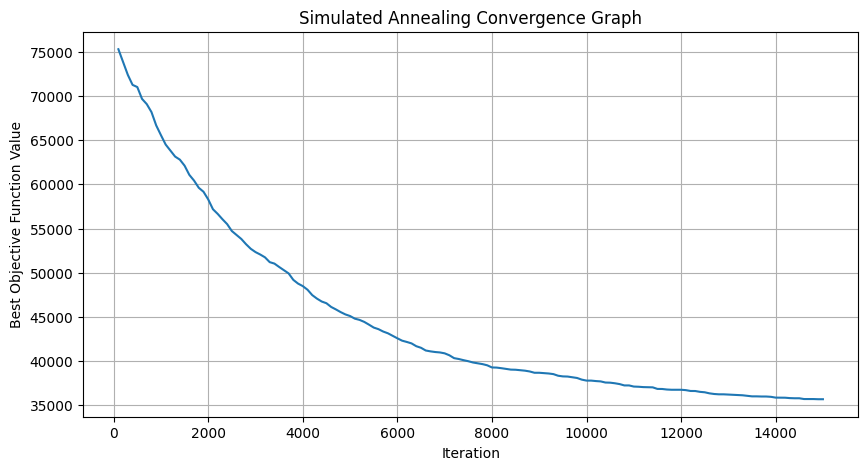

In [13]:
# ------------------------------------------------------------
# 6. CONVERGENCE GRAPH
# ------------------------------------------------------------

iteration_axis = np.arange(100, (len(convergence) + 1) * 100, 100)

plt.figure(figsize=(10, 5))
plt.plot(iteration_axis, convergence)

plt.title("Simulated Annealing Convergence Graph")
plt.xlabel("Iteration")
plt.ylabel("Best Objective Function Value")
plt.grid(True)

plt.show()

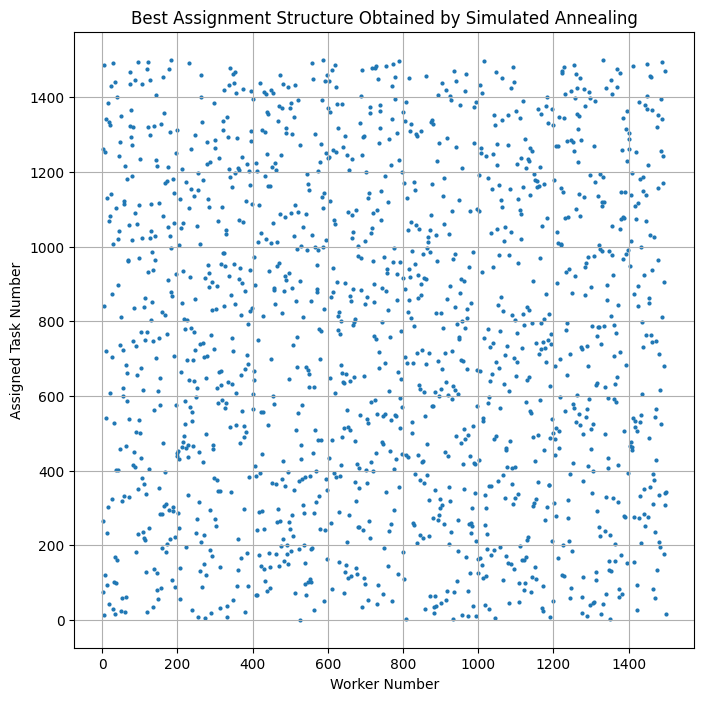

In [14]:
# ------------------------------------------------------------
# 7. ASSIGNMENT VISUALISATION
# ------------------------------------------------------------

plt.figure(figsize=(8, 8))

plt.scatter(
    np.arange(1, n + 1),
    best_solution + 1,
    s=4
)

plt.title("Best Assignment Structure Obtained by Simulated Annealing")
plt.xlabel("Worker Number")
plt.ylabel("Assigned Task Number")
plt.grid(True)

plt.show()

In [15]:
# ------------------------------------------------------------
# 8. SAVE FINAL SOLUTION AS CSV
# ------------------------------------------------------------

with open("best_assignment_solution.csv", "w", newline="") as csv_file:

    writer = csv.writer(csv_file)

    writer.writerow([
        "Worker",
        "Assigned Task",
        "Assignment Cost"
    ])

    for i in range(n):
        writer.writerow([
            i + 1,
            int(best_solution[i]) + 1,
            int(cost_matrix[i][best_solution[i]])
        ])

print("CSV file created successfully.")
print("File name: best_assignment_solution.csv")

CSV file created successfully.
File name: best_assignment_solution.csv


In [16]:
from google.colab import files

files.download("best_assignment_solution.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>